### ECE/CS/ISyE 524 &mdash; Introduction to Optimization ###

# Traffic Police Platform Distribution #

#### Blake Holman (bholman2@wisc.edu), Yue Huang (yhuang675@wisc.edu), Hande Kong (hkong29@wisc.edu)

*****

### Table of Contents

1. [Introduction](#1.-Introduction)
1. [Mathematical Model](#2.-Mathematical-model)
1. [Solution](#3.-Solution)
1. [Results and Discussion](#4.-Results-and-Discussion)
1. [Conclusion](#5.-Conclusion)

## 1. Introduction ##

Police officers are responsible for law enforcement, crime prevention, traffic management, and serving the community.
To effectively carry out these duties, it is necessary to set up police patrol service platforms at certain key locations along the city's major traffic arteries and important points. The functions and police resource allocations of each patrol service platform are roughly the same.
Since police resources are limited, how to reasonably determine the locations of patrol service platforms according to the actual situation and demands of the city, allocate the jurisdiction areas of each platform, and coordinate police resources efficiently, is a real-world problem faced by police departments.

This study focuses on the relevant situation of setting up police patrol service platforms in the city and builds mathematical models to analyze and solve the following problems.

---

**Scenario 1**

Using the traffic network of District A in the city center as the research object, based on the traffic network and the current locations of the 20 police patrol service platforms, assign a jurisdiction area to each platform. Ensure that when an emergency occurs within the jurisdiction, a patrol officer can arrive at the incident location within 3 minutes as much as possible (assuming the police vehicle speed is 60 km/h).

---

**Scenario 2**

In the case of a major emergency, it is necessary to mobilize police resources from all 20 police patrol service platforms to quickly blockade the 13 critical traffic exits in the area. In practice, each platform can lock at most one intersection. This Scenario aims to design a reasonable police resource dispatch plan for the blocking plan in District A.

---

**Scenario 3**

Based on the current imbalance in workload across each platform and the actual situation where some locations have excessively long police dispatch times, it is proposed to add 4 platforms in the area. Determine the specific number of platforms that need to be added.


## 2. Mathematical model ##

**All calculations are performed under the following assumptions:**

(1) It is assumed that all roads are bidirectional.

(2) It is assumed that each service platform has sufficient resources. Except for the police units already on patrol, there are always enough forces at the service platforms to dispatch to the incident location after receiving an emergency call.

(3) Traffic signals and congestion are ignored, meaning police vehicles travel from the service platform to the incident site without any interruptions.

(4) It is assumed that police vehicles travel at a constant speed during their journey.


**Symbol Description:**

- $D_{ij}$: shortest distance from platform $i$ to node $j$
- $v$: police vehicle speed (in km/min)
  
## Scenario 1 

**Problem Analysis**

This problem requires the delineation of the jurisdiction for 20 police service platforms, ensuring that each platform can reach any road intersection within its jurisdiction within 3 minutes. Therefore, from the problem's nature, it falls under the category of public policy planning problems and is suitable for mathematical modeling. 

Based on 'data_nodes', which provides the geographic coordinates of each road intersection and the connection relationships, and the locations of the 20 police service platforms, this project employs 0-1 integer programming to construct a model.

First, using the coordinates, the paths between each platform and road node are derived, and the shortest path between them is calculated by Dijkstra. It is then determined whether the platform can reach the intersection within 3 minutes. Next, an optimization model is constructed: to minimize the total service distance.

For intersections that cannot be reached within 3 minutes by any platform, the platform with the smallest distance is selected to serve these special nodes. 

**Solution**

**Step1:Generate the shortest path martix $ D $ from 20 platform to all junctions**

**Step2:Formulate the Optimization Model**

**Variables:**

- $x_{ij} \in \{0, 1\}$: 1 if platform $i$ is responsible for node $j$, otherwise 0.
  
  Where $i \in \{1, \ldots, 20\}$, $j \in \{1, \ldots, 92\}$.

---

**Constraints:**

**1. Distance Constraint**

If the shortest distance $D_{ij} > 3$ km and node $j$ is not a special node, then: $x_{ij} = 0$


(Platforms cannot serve nodes that are farther than 3 km away unless they are special.)

**2. Assignment Constraint**

For each normal (non-special) node $j$, it must be assigned to exactly one platform:

$$
\sum_{i=1}^{m} x_{ij} = 1, \quad \forall j \notin \text{special\_nodes}
$$

---

**Objective:**

Minimize the total service distance:

$$
\min \sum_{i=1}^{m} \sum_{j=1}^{n} D_{ij} \cdot x_{ij}
$$

(Minimize the total sum of distances between platforms and their assigned nodes.)

**Step3:Find the nearest platform for all special junction**

## Scenario 2 

**Problem Analysis**

This problem requires designing a reasonable police force allocation scheme for platforms. It demands that the 20 platforms in A achieve rapid lockdown of 13 critical traffic exits. Therefore, by nature, the problem belongs to the category of resource allocation problems.

Since each platform can block at most one road at a time, and considering the goal of finding the optimal allocation, 13 platforms are dispatched simultaneously, each platform blocks one road, to achieve full lockdown coverage of the exits as quickly as possible.

The problem is further transformed into an assignment optimization problem to minimize the maximum dispatch time of any platform. Based on the distances between the 20 patrol platforms and the 13 exits, and assuming a vehicle speed of 60 km/h, a 0-1 integer programming model is constructed to achieve the objective of minimizing the maximum arrival time.

---

**Solution**

**Step1: Generate the shortest path martix $ D $ from 20 platform to all exit junctions**

**Step2: Formulate the optimization model to minimize the maximmum dispatch time for all exit junctions**

**Variables**

- $x_{ij} \in \{0, 1\}$: 1 if platform $i$ is responsible for node $j$, otherwise 0.

Where $i \in \{1, \ldots, 20\}$, $j \in \{1, \ldots, 13\}$.

---

**Constraints**

1. Each exit node must be blocked by exactly one platform:

$$
\sum_{i=1}^{20} x_{ij} = 1, \quad \forall j \in \{1, \ldots, 13\}
$$

2. Each platform can block at most one exit junction:

$$
\sum_{j=1}^{13} x_{ij} \leq 1, \quad \forall i \in \{1, \ldots, 20\}
$$

---

**Objective: Minimize the maximum dispatch time**

We aim to minimize the maximum dispatch time from any platform to the junctions it is responsible for.

$$
t_i = \max_{1 \leq j \leq n} \left( \frac{d_{ij} \cdot x_{ij}}{v} \right), \quad \forall i \in \{1, \ldots, m\}
$$

$$
T = \max_{1 \leq i \leq m} t_i
$$

Objective Function

Minimize:

$$
\min T
$$

---

**Step3: Formulate the optimization model to minimize the total dispatch time for all exit junctions**

Based on the maximum dispatch time $T_{\text{opt}}$ obtained from Step2, we aim to reassign platforms to exit junctions in order to minimize the total dispatch time, under the condition that each assignment must still meet the maximum time limit $T_{\text{opt}}$.


**Variables**


- $x_{ij} \in \{0, 1\}$: 1 if platform $i$ is responsible for node $j$, otherwise 0.

 Where $i \in \{1, \ldots, 20\}$, $j \in \{1, \ldots, 13\}$.
 
---

**Constraints**

1. **Assignment Constraint (Each junction is covered once):**

   $$
   \sum_{i=1}^{m} x_{ij} = 1, \quad \forall j \in \{1, \dots, n\}
   $$

2. **Capacity Constraint (Each platform can take at most one junction):**

   $$
   \sum_{j=1}^{n} x_{ij} \leq 1, \quad \forall i \in \{1, \dots, m\}
   $$

3. **Dispatch Time (All assignments within $T_{\text{opt}}$):**

   $$
   \frac{D_{ij}}{v} \cdot x_{ij} \leq T_{\text{opt}}, \quad \forall i, j
   $$

---

**Objective:Minimize the total dispatch time**

Minimize the total dispatch time across all assignments:

$$
\min \sum_{i=1}^{m} \sum_{j=1}^{n} \frac{D_{ij}}{v} \cdot z_{ij}
$$



## Scenario 3 

**Problem Analysis**

From the results of the first sub-question, it can be seen that the 20 platforms in Area A cover different ranges; therefore, these two factors result in an uneven workload and longer response times for some platforms. This problem can be solved by adding 4 platforms.

Based on the problem description, we can divide this problem into two issues: (1) minimizing the maximum dispatch time after adding 4 platforms, and (2) minimizing the variance in workload distribution.

**Solution**

**Step1: Generate the shortest path martix $ D $ from 92 junctions to all other junctions**

**Step2: Formulate the optimization model to minimize the maximmum dispatch time after adding 4 platforms**


**Variables**
- $x_{ij} \in \{0, 1\}$: 1 if platform $i$ is responsible for node $j$, otherwise 0.
- $P_i \in \{0, 1\}$: 1 if a platform is placed at node $i$, otherwise 0.
- $T \geq 0$: The maximum response time to be minimized.

**Constraints:**

1. **Existing Platforms Constraint**  
   For all $i \in \{1, 2, \dots, 20\}$:  
   $$ P_i = 1 $$

2. **New Platform Limit**  
   Exactly 4 additional platforms can be placed at nodes $21$ to $92$:  
   $$ \sum_{i=21}^{92} P_i = 4 $$

3. **Distance Feasibility Constraint**  
   If distance exceeds threshold (e.g., 3 km), assignment is not allowed:  
   $$ \text{If } D_{ij} > 3, \quad x_{ij} = 0 $$

4. **Unique Assignment Constraint**  
   Each node $j$ must be assigned to exactly one platform:  
   $$ \sum_{i=1}^{n} x_{ij} = 1 \quad \forall j \in \{1,\dots,n\} $$

5. **Assignment Only to Platform Nodes**  
   Nodes can only be assigned to active platforms:  
   $$ x_{ij} \leq P_i \quad \forall i, j $$

6. **Maximum Dispatch Time Constraint**  
   The dispatch time for each assignment must be bounded by the max $T$:  
   $$ T \geq \frac{D_{ij}}{v} \cdot x_{ij} \quad \forall i,j $$

**Objective:**
Minimize the maximum dispatch time:

$$
\min T
$$

---


**Step3: Formulate the optimization model to minimize the variance of workload after adding 4 platforms based on the optimal maximum dispatch time in Step2**

**Variables:**
- $x_{ij} \in \{0,1\}$: 1 if platform $i$ is responsible for junction $j$, otherwise 0
- $P_i \in \{0,1\}$: 1 if a platform is placed at junction $i$, otherwise 0
- $e_i \geq 0$: absolute deviation of platform $i$ from the target workload
- $l_i = \sum_{j=1}^{92} x_{ij} \cdot \text{nodes\_warning}[j]$: total workload for platform $i$

**Parameters:**

- $T_{\text{opt}}$: optimal maximum dispatch time obtained in step2
- $\text{nodes\_warning}[j]$: warning count at junction $j$
- $\bar{g} = \dfrac{1}{24} \sum_{j=1}^{92} \text{nodes\_warning}[j]$: average workload per platform
- $\text{target}_i = P_i \cdot \bar{g}$
  
**Constraints**

1. **Workload Bound:**
   $$
e_i = \left| l_i - \text{target}_i \right|
$$

    To transform an absolute value constraint into a form that can be handled by solvers, it is rewritten as two linear inequalities. 

   $$
   \text{l}_i - \text{target}_i \leq e_i \quad \forall i = 1, \dots, 92
   $$
   $$
   \text{target}_i - \text{l}_i \leq e_i \quad \forall i = 1, \dots, 92
   $$

3. **Platform Count Constraint:**
   $$
   \sum_{i=21}^{92} P_i = 4
   $$
   $$
   P_i = 1 \quad \forall i = 1, \dots, 20
   $$

4. **Unique Assignment:**
   $$
   \sum_{i=1}^{92} x_{ij} = 1 \quad \forall j = 1, \dots, 92
   $$

5. **Platform Activation Constraint:**
   $$
   x_{ij} \leq P_i \quad \forall i, j
   $$

6. **Dispatch Time Limit:**
   $$
   \frac{D_{ij}}{v} \cdot x_{ij} \leq T_{\text{opt}} \quad \text{(if not, } x_{ij} = 0)
   $$

---
**Objective**
Minimize the total deviation from average workload:

$$
\min \sum_{i=1}^{92} e_i
$$

## 3. Solution ##
## Scenario 1 

Generate the graph for the traffic network and police platform distribution

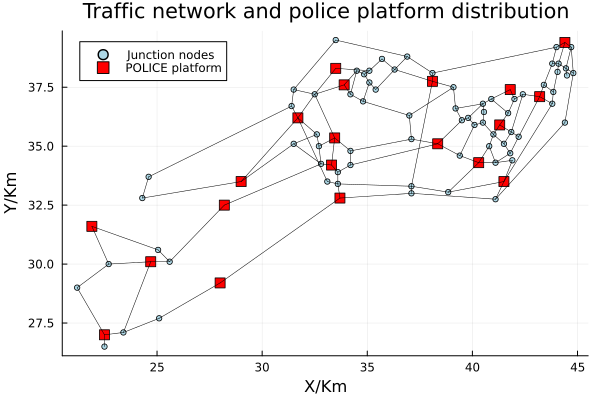

In [2]:
using CSV,DataFrames,Plots

nodes = CSV.read("data_nodes.csv", DataFrame)
nodes_number = nodes[:, 1]
nodes_x = nodes[:, 2]./10
nodes_y = nodes[:, 3]./10

links = CSV.read("data_links.csv", DataFrame)
links_start = links[:,1]
links_end = links[:,2]

network = plot(size=(600,400))

scatter!(network, nodes_x, nodes_y, label="Junction nodes", color=:lightblue, ms=3)
scatter!(network, nodes_x[1:20], nodes_y[1:20], label="POLICE platform", color=:red, ms=5, marker=:square)

for (i, j) in zip(links_start, links_end)
    plot!(network, [nodes_x[i], nodes_x[j]], [nodes_y[i], nodes_y[j]], color=:black, lw=0.5, label="")
end

xlabel!("X/Km")
ylabel!("Y/Km")
title!("Traffic network and police platform distribution")
plot!(network, grid=true, legend=true)  
display(network)

Generate the shortest path matrix by dijkstra algorithm.

In [3]:
using Graphs, SimpleWeightedGraphs, JuMP, GLPK, LinearAlgebra

g = SimpleWeightedGraph(92)

for (i, j) in zip(links_start, links_end)
    dist = sqrt((nodes_x[i] - nodes_x[j])^2 + (nodes_y[i] - nodes_y[j])^2)
    add_edge!(g, i, j, dist)  
end

m, n = 20, 92
D = zeros(m, n)

for (platform_id, platform_idx) in enumerate(1:m)
    sp = dijkstra_shortest_paths(g, platform_idx)
    for node_idx in 1:n
        D[platform_id, node_idx] = sp.dists[node_idx]
    end
end
println("The Matrix of Dijkstra shortest path is:")
D

The Matrix of Dijkstra shortest path is:


20×92 Matrix{Float64}:
  0.0       1.89875   3.88388   4.87932  …   4.51713   5.09523   7.33196
  1.89875   0.0       2.11165   5.68507      6.33732   6.91541   8.0728
  3.88388   2.11165   0.0       4.04339      7.84747   8.42556  10.1844
  4.87932   5.68507   4.04339   0.0          7.73323   8.08693  10.3237
  9.60594   7.83371   5.72206   4.92004     12.6383   12.992    15.2287
  9.88162   9.84208   7.73042   5.0023   …  12.7206   13.0743   15.311
 11.5003    9.72812   7.61647   7.65669     15.375    15.7287   15.9922
  9.02262   7.25039   5.13874   8.32728     12.9862   13.5643   14.5249
  9.22544   7.45321   5.34155   8.98667     13.189    13.7671   13.3652
 14.6496   12.8773   10.7657   14.4108      18.6132   19.1912   18.7893
 19.0879   17.3157   15.204    18.8492   …  23.0515   23.6296   23.2277
 22.2362   20.4639   18.3523   21.9974      26.1997   26.7778   26.3759
 22.0018   20.103    18.7405   20.9818      26.2747   27.0184   24.7603
 16.0285   14.1297   12.7672   15.0085   

Find the far nodes from all platforms

In [4]:
function check_nodes(D, distance)
    n_nodes = size(D, 2) 
    n_platforms = size(D, 1) 
    faraway_nodes = Int[] 

    for j in 1:n_nodes 
        all_far = true
        for i in 1:n_platforms 
            if D[i, j] <= distance
                all_far = false
                break
            end
        end
        if all_far
            push!(faraway_nodes, j)
        end
    end

    return faraway_nodes
end
far_nodes = check_nodes(D, 3.0)

println("The node numbers away from all platforms are：", far_nodes)

The node numbers away from all platforms are：[28, 29, 38, 39, 61, 92]


Generate the optimization model to distribute the 92 junctions for 20 platforms.

In [5]:
model = Model(GLPK.Optimizer) 
special_nodes = [28, 29, 38, 39, 61, 92]
@variable(model, x[1:m, 1:n], Bin)

for i in 1:m, j in 1:n
    if (D[i,j] > 3) && (!(j in special_nodes))
        @constraint(model, x[i,j] == 0)
    end
end

for j in 1:n
    if (!(j in special_nodes))
    @constraint(model, sum(x[i,j] for i in 1:m) == 1)
    end
end

@objective(model, Min, sum(D[i,j] * x[i,j] for i in 1:m, j in 1:n))

optimize!(model)
println("The optimal total distance is：", objective_value(model),"Km")
x_opt = value.(x)
for i in 1:m
    assigned = findall(x_opt[i, :] .> 0.5)
    println("Platform ", i, " is reponsible for platforms：", assigned)
end

The optimal total distance is：78.76629472790057Km
Platform 1 is reponsible for platforms：[1, 67, 68, 69, 71, 73, 74, 75, 78]
Platform 2 is reponsible for platforms：[2, 40, 43, 44, 70, 72]
Platform 3 is reponsible for platforms：[3, 54, 55, 65, 66]
Platform 4 is reponsible for platforms：[4, 57, 60, 62, 63, 64]
Platform 5 is reponsible for platforms：[5, 49, 50, 51, 52, 53, 56, 58, 59]
Platform 6 is reponsible for platforms：[6]
Platform 7 is reponsible for platforms：[7, 30, 32, 47, 48]
Platform 8 is reponsible for platforms：[8, 33, 46]
Platform 9 is reponsible for platforms：[9, 31, 34, 35, 45]
Platform 10 is reponsible for platforms：[10]
Platform 11 is reponsible for platforms：[11, 26, 27]
Platform 12 is reponsible for platforms：[12, 25]
Platform 13 is reponsible for platforms：[13, 21, 22, 23, 24]
Platform 14 is reponsible for platforms：[14]
Platform 15 is reponsible for platforms：[15]
Platform 16 is reponsible for platforms：[16, 36, 37]
Platform 17 is reponsible for platforms：[17, 41, 42]

Generate the graph of distribution of the network platform.

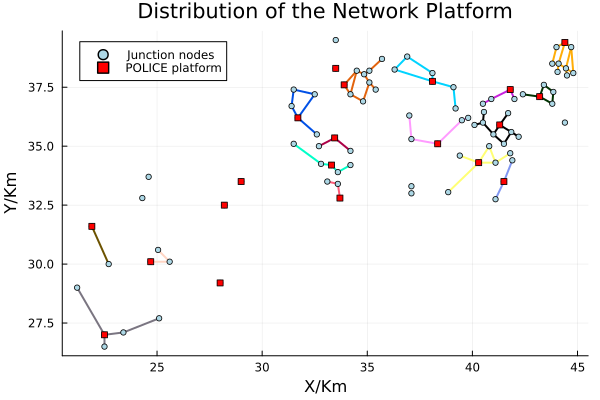

In [6]:
using Random

assigned_nodes = [findall(x_opt[i, :] .> 0.5) for i in 1:20]
network_Dist = plot(size=(600,400))
colors = distinguishable_colors(20)

for platform_id in 1:20
    platform_nodes = assigned_nodes[platform_id]

    for (i, j) in zip(links_start, links_end)
       if (i in platform_nodes) && (j in platform_nodes)
            plot!(network_Dist , [nodes_x[i], nodes_x[j]], [nodes_y[i], nodes_y[j]],
                color=colors[platform_id], lw=2, label=false)
        end
    end

end
scatter!(network_Dist, nodes_x, nodes_y, label="Junction nodes", color=:lightblue, ms=3)
scatter!(network_Dist, nodes_x[1:20], nodes_y[1:20], label="POLICE platform", color=:red, ms=3, marker=:square)

xlabel!("X/Km")
ylabel!("Y/Km")
title!("Distribution of the Network Platform")
plot!(network_Dist , grid=true)
display(network_Dist)

Distribute the far junctions to the nearest platform

In [7]:
special_nodes = [28, 29, 38, 39, 61, 92]

for node in special_nodes
    min_dist, best_platform = findmin(D[:, node])
    println("The nearest platform for ", node, " is ", best_platform, ". The distance is ", min_dist)
end

The nearest platform for 28 is 15. The distance is 4.751841748206688
The nearest platform for 29 is 15. The distance is 5.700525046257208
The nearest platform for 38 is 16. The distance is 3.4058772731852787
The nearest platform for 39 is 2. The distance is 3.6821859248740303
The nearest platform for 61 is 7. The distance is 4.190201970671075
The nearest platform for 92 is 20. The distance is 3.6028470619083235


Generate the graph of new distribution of the network platform

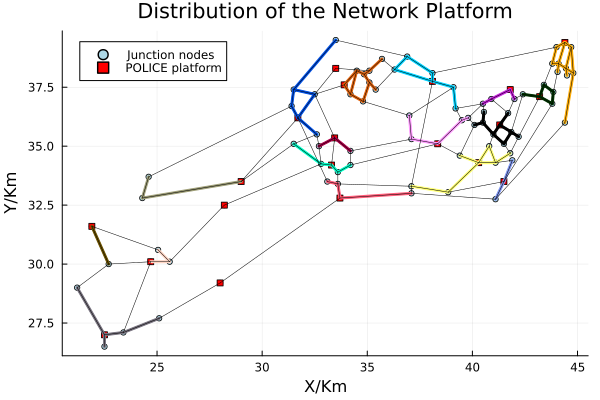

In [8]:
push!(assigned_nodes[15], 28)
push!(assigned_nodes[15], 29)
push!(assigned_nodes[16], 38)
push!(assigned_nodes[2], 39)
push!(assigned_nodes[7], 61)
push!(assigned_nodes[20], 92)

for platform_id in 1:20
    platform_nodes = assigned_nodes[platform_id]

    for (i, j) in zip(links_start, links_end)
       if (i in platform_nodes) && (j in platform_nodes)
            plot!(network_Dist , [nodes_x[i], nodes_x[j]], [nodes_y[i], nodes_y[j]],
                color=colors[platform_id], lw=3, label=false)
        end
    end
end

for (i, j) in zip(links_start, links_end)
    plot!(network_Dist, [nodes_x[i], nodes_x[j]], [nodes_y[i], nodes_y[j]], color=:black, lw=0.5, label="")
end
display(network_Dist)

## Scenario 2

Generate the graph of the exit junction 

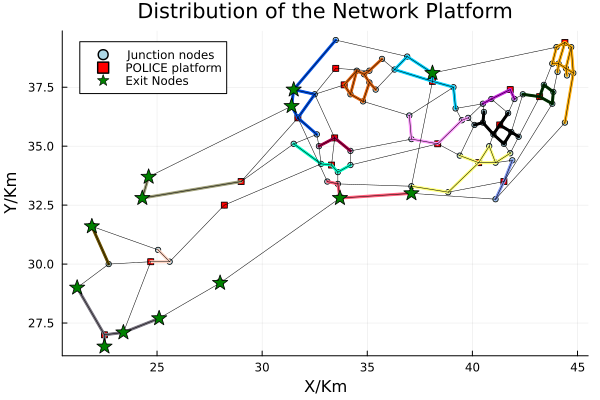

In [9]:
exit = CSV.read("data_exit.csv", DataFrame)
nodes_exit = exit[:,1]
scatter!(network_Dist, nodes_x[nodes_exit], nodes_y[nodes_exit],color=:Green, marker=:star, ms=8, label="Exit Nodes")
display(network_Dist)

Generate the shortest path matrix path from the platforms to all exit junctions

In [10]:
platform_nodes = 1:20
D_platform_exit = D[platform_nodes,nodes_exit]

20×13 Matrix{Float64}:
 22.2362   16.0285    9.28681  19.2934   …   5.88093  12.0818    5.22932
 20.4639   14.1297    7.38806  17.3947       3.98219  10.3095    6.03507
 18.3523   12.7672    6.02557  16.0322       6.09384   8.19788   4.39339
 21.9974   15.0085    8.26685  18.2735       4.86098   7.39587   0.35
 17.6282   12.9696    6.22797  16.2346       9.42112   2.47583   5.25507
 17.6588   13.0002    6.25855  16.2652   …   9.4517    2.50641   5.33733
 14.9149   10.9012    4.15956  14.1662       7.35271   1.2902    7.99172
 14.0925    9.43394   2.69228  12.6989       5.88543   3.09947   8.67728
 13.0107    8.2742    1.53254  11.5392       4.72569   4.19941   9.33667
  7.58659  12.7757    6.95667   9.51069     10.1498    8.61855  14.7608
  3.79135   8.3373   11.395     5.07233  …  14.5882   13.0569   19.1992
  0.0      11.9503   14.5433    8.68532     17.7364   16.2051   22.3474
  5.977     5.97328  12.7149    2.70831     16.1208   17.232    21.3318
 11.9503    0.0       6.74166   3.2

Generate the optimization model about the distribution blocking junction, to minimize the maximum time.

In [11]:
using JuMP, GLPK

model_2 = Model(GLPK.Optimizer)
m = 20
n = 13
v = 1
@variable(model_2, z[1:m, 1:n], Bin)
@variable(model_2, T >= 0)

for j in 1:n
    @constraint(model_2, sum(z[i, j] for i in 1:m) == 1)
end

for i in 1:m
    @constraint(model_2, sum(z[i, j] for j in 1:n) <= 1)
end

for i in 1:m, j in 1:n
    @constraint(model_2, T >= D_platform_exit[i,j] * z[i,j]/v)
end

@objective(model_2, Min, T)

optimize!(model_2)

z_opt = value.(z)
for i in 1:m, j in 1:n
    if z_opt[i,j] > 0.5
        println("Platform $i is responsible for " , nodes_exit[j])
    end
end
println("The minimum blocking time for the blocking scheme is: ", objective_value(model_2),"min")

Platform 1 is responsible for 38
Platform 2 is responsible for 62
Platform 3 is responsible for 16
Platform 4 is responsible for 48
Platform 5 is responsible for 30
Platform 7 is responsible for 29
Platform 10 is responsible for 22
Platform 11 is responsible for 24
Platform 12 is responsible for 23
Platform 13 is responsible for 12
Platform 14 is responsible for 21
Platform 15 is responsible for 28
Platform 16 is responsible for 14
8.015456859909346min time for the blocking scheme is: 


Calculate the total time spent to block all the exit junctions

In [12]:
assigned_pairs = [(1, 38),(2, 62),(3, 16),(4, 48),(5, 30),(7, 29),
    (10, 22),(11, 24),(12, 23),(13, 12), (14, 21),(15, 28),(16, 14)]

total_time = sum(D[i,j] for (i,j) in assigned_pairs)
println("The total blocking time for the blocking scheme is: ",total_time,"min")

The total blocking time for the blocking scheme is: 75.26149202390067min


Considering the total time spent for the blocking scheme is to long, here try to minimize the total time.

In [13]:
T_opt = value(T) 
z_opt = value.(z) 
model_3 = Model(GLPK.Optimizer)
@variable(model_3, z_new[1:m, 1:n], Bin)

for j in 1:n
    @constraint(model_3, sum(z_new[i, j] for i in 1:m) == 1)
end

for i in 1:m
    @constraint(model_3, sum(z_new[i, j] for j in 1:n) <= 1)
end

for i in 1:m, j in 1:n
    @constraint(model_3, D_platform_exit[i, j]/v * z_new[i, j] <= T_opt)
end

@objective(model_3, Min, sum(D_platform_exit[i, j]/v * z_new[i, j] for i in 1:m, j in 1:n))

optimize!(model_3)

z_final = value.(z_new)
for i in 1:m, j in 1:n
    if z_final[i,j] > 0.5
        println("Platform $i is responsible for " , nodes_exit[j])
    end
end
println("The total blocking time for the new blocking scheme is: ", objective_value(model_3),"min")

Platform 2 is responsible for 38
Platform 4 is responsible for 62
Platform 5 is responsible for 48
Platform 7 is responsible for 29
Platform 8 is responsible for 30
Platform 9 is responsible for 16
Platform 10 is responsible for 22
Platform 11 is responsible for 24
Platform 12 is responsible for 12
Platform 13 is responsible for 23
Platform 14 is responsible for 21
Platform 15 is responsible for 28
Platform 16 is responsible for 14
The total blocking time for the new blocking scheme is: 46.188489453475206min


Calculate the new total time spent to block all the exit junctions after reassignment

In [14]:
assigned_pairs_new = [(2, 38), (4, 62), (5, 48), (7, 29), (8, 30), (9, 16), (10, 22),
    (11, 24), (12, 12), (13, 23), (14, 21), (15, 28), (16, 14)]

total_time_new = sum(D[i,j] for (i,j) in assigned_pairs_new)
println("The total blocking time for the blocking scheme is: ",total_time_new,"min")

The total blocking time for the blocking scheme is: 46.188489453475206min


Generate the new graph for the paths from platforms to exits

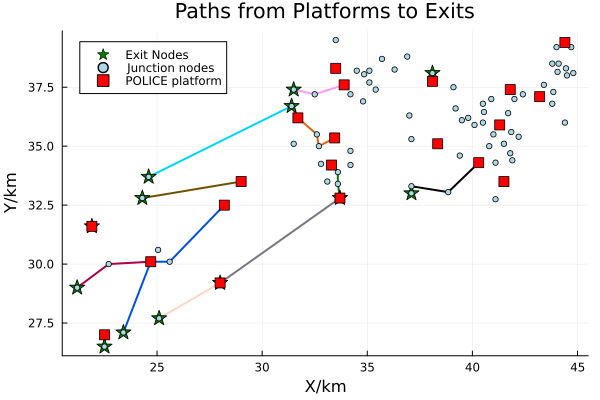

In [15]:
using Plots

network_path = plot(size=(600, 400))

colors = distinguishable_colors(length(assigned_pairs_new))

for (idx, (start_node, end_node)) in enumerate(assigned_pairs_new)
    sp = dijkstra_shortest_paths(g, start_node)

    current = end_node
    path = Int[]
    while current != start_node
        if current == 0
            break
        end
        push!(path, current)
        current = sp.parents[current]
    end
    push!(path, start_node)
    reverse!(path)

    for i in 1:length(path)-1
        plot!(network_path,[nodes_x[path[i]], nodes_x[path[i+1]]],
              [nodes_y[path[i]], nodes_y[path[i+1]]],
              color=colors[idx], lw=2, label=false)
    end
end
scatter!(network_path, nodes_x[nodes_exit], nodes_y[nodes_exit],color=:Green, marker=:star, ms=8, label="Exit Nodes")
scatter!(network_path, nodes_x, nodes_y, label="Junction nodes", color=:lightblue, ms=3)
scatter!(network_path, nodes_x[1:20], nodes_y[1:20], label="POLICE platform", color=:red, ms=5, marker=:square)

xlabel!("X/km")
ylabel!("Y/km")
title!("Paths from Platforms to Exits")
plot!(network_path, grid=true)

display(network_path)



## Scenario 3

Generate the shortest path matrix path for all junctions

In [16]:
g_new = SimpleWeightedGraph(92)

for (i, j) in zip(links_start, links_end)
    dist = sqrt((nodes_x[i] - nodes_x[j])^2 + (nodes_y[i] - nodes_y[j])^2)
    add_edge!(g_new, i, j, dist)  
end

n_new = 92

D_new = fill(Inf, n_new, n_new)  
for i in 1:n
    D_new[i,i] = 0.0 
end

for i in 1:n_new
    sp = dijkstra_shortest_paths(g_new, i)
    for j in 1:n_new
        D_new[i,j] = sp.dists[j]
    end
end
D_new

92×92 Matrix{Float64}:
  0.0       1.89875   3.88388   4.87932  …   4.51713    5.09523    7.33196
  1.89875   0.0       2.11165   5.68507      6.33732    6.91541    8.0728
  3.88388   2.11165   0.0       4.04339      7.84747    8.42556   10.1844
  4.87932   5.68507   4.04339   0.0          7.73323    8.08693   10.3237
  9.60594   7.83371   5.72206   4.92004     12.6383    12.992     15.2287
  9.88162   9.84208   7.73042   5.0023   …  12.7206    13.0743    15.311
 11.5003    9.72812   7.61647   7.65669     15.375     15.7287    15.9922
  9.02262   7.25039   5.13874   8.32728     12.9862    13.5643    14.5249
  9.22544   7.45321   5.34155   8.98667     13.189     13.7671    13.3652
 14.6496   12.8773   10.7657   14.4108      18.6132    19.1912    18.7893
 19.0879   17.3157   15.204    18.8492   …  23.0515    23.6296    23.2277
 22.2362   20.4639   18.3523   21.9974      26.1997    26.7778    26.3759
 22.0018   20.103    18.7405   20.9818      26.2747    27.0184    24.7603
  ⋮            

Generate the model to minimize the maximum dispatch time after adding 4 new platforms

In [17]:
using JuMP, GLPK

n = 92 
m = 20 
model_3 = Model(GLPK.Optimizer)

@variable(model_3, P[1:n], Bin)
@variable(model_3, x[1:n, 1:n], Bin) 
@variable(model_3, T >= 0)         

for i in 1:m
    @constraint(model_3, P[i] == 1)
end

@constraint(model_3, sum(P[i] for i in 21:n) == 4)

for i in 1:n, j in 1:n
    if  D_new[i,j] > 3
        @constraint(model_3, x[i,j] == 0)
    end
end

for j in 1:n
    @constraint(model_3, sum(x[i,j] for i in 1:n) == 1)
end

for i in 1:n, j in 1:n
    @constraint(model_3, x[i,j] <= P[i])
end

for i in 1:n, j in 1:n
    @constraint(model_3, T >= D_new[i,j] * x[i,j])
end

@objective(model_3, Min, T)
optimize!(model_3)

println("The optimal maximum time is：", objective_value(model_3)," min")

T_opt = value.(T)
x1_opt = value.(x)
z_opt = value.(z)
for i in 1:n
    if sum(x1_opt[i, :])>=1
    assigned = findall(x1_opt[i, :] .> 0.5)
    println("Platform ", i, " is reponsible for platforms：", assigned)
    end
end

The optimal maximum time is：2.708314151545737 min
Platform 1 is reponsible for platforms：[1, 42, 43, 65, 66, 68, 69, 70, 71, 72, 73, 74, 76, 78, 79, 80]
Platform 2 is reponsible for platforms：[2, 44, 67, 75]
Platform 3 is reponsible for platforms：[3, 54, 55, 64]
Platform 4 is reponsible for platforms：[4, 57, 58, 60, 62, 63]
Platform 5 is reponsible for platforms：[5, 49, 50, 53, 56, 59]
Platform 6 is reponsible for platforms：[6, 47, 48, 51, 52]
Platform 7 is reponsible for platforms：[7, 30, 33, 34]
Platform 8 is reponsible for platforms：[8, 31, 32, 35, 36, 37, 45, 46]
Platform 9 is reponsible for platforms：[9]
Platform 10 is reponsible for platforms：[10]
Platform 11 is reponsible for platforms：[11, 25, 26, 27]
Platform 12 is reponsible for platforms：[12]
Platform 13 is reponsible for platforms：[13, 21, 22, 23, 24]
Platform 14 is reponsible for platforms：[14]
Platform 15 is reponsible for platforms：[15]
Platform 16 is reponsible for platforms：[16]
Platform 17 is reponsible for platforms：

Generate the graph for the new policce platforms based on the maximum dispatch time

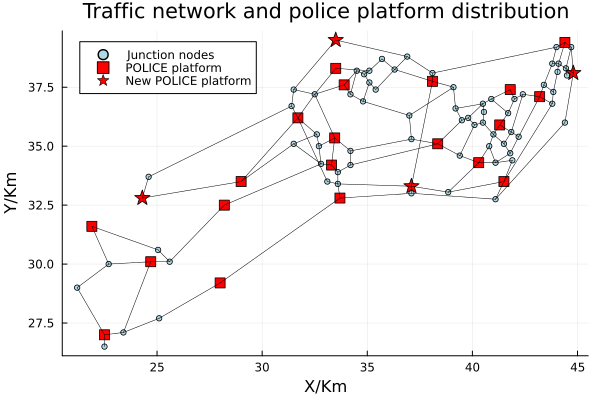

In [18]:
new_platform = [28, 39, 61, 87]

network_new = plot(size=(600,400))

scatter!(network_new, nodes_x, nodes_y, label="Junction nodes", color=:lightblue, ms=3)
scatter!(network_new, nodes_x[1:20], nodes_y[1:20], label="POLICE platform", color=:red, ms=5, marker=:square)
scatter!(network_new, nodes_x[new_platform], nodes_y[new_platform], label="New POLICE platform", color=:red, ms=8, marker=:star)

for (i, j) in zip(links_start, links_end)
    plot!(network_new, [nodes_x[i], nodes_x[j]], [nodes_y[i], nodes_y[j]], color=:black, lw=0.5, label="")
end

xlabel!("X/Km")
ylabel!("Y/Km")
title!("Traffic network and police platform distribution")
plot!(network_new, grid=true, legend=true)  
display(network_new)

Considering the imbalance of the workload for each platform, here we can calculated the variance to evaluate the workload.

In [19]:
nodes_warning = nodes[ :,4]
ḡ = sum(nodes_warning[j] for j in 1:92) / 24
target = ḡ*ones(length(nodes_warning))
total_deviation_1 = 0.0
workload_1 = []
for i in 1:92
    if sum(x1_opt[i, :]) > 0
        weighted_sum = sum(x1_opt[i, :] .* nodes_warning)
        push!(workload_1,weighted_sum)
        total_deviation_1 += (weighted_sum - ḡ)^2
    end
end
println("The workload for each platform is: ",workload_1)
println("The variance of workload for each platform is: ",total_deviation_1/24)

The workload for each platform is: Any[16.6, 4.800000000000001, 4.9, 6.8999999999999995, 7.200000000000001, 6.9, 7.6, 10.7, 2.1, 1.6, 6.2, 2.4, 8.5, 2.5, 2.1, 2.6, 5.6, 13.500000000000002, 1.8, 3.3, 2.7, 2.5999999999999996, 0.6, 0.8]
The variance of workload for each platform is: 15.821093750000005


Based on the optimal maximum dispatch time, generate the optimization model to minimize the variance of workload for each platform.

In [20]:
using Mosek,MosekTools
model_4 = Model(Mosek.Optimizer)
set_silent(model_4)
@variable(model_4, x[1:92, 1:92], Bin)
@variable(model_4, z[1:92], Bin)
@variable(model_4, e[1:92]) 

@expression(model_4, l[i=1:92], sum(x[i,j] * nodes_warning[j] for j in 1:92))

@constraint(model_4, [i=1:92], l[i] - target[i] <= e[i])
@constraint(model_4, [i=1:92], target[i] - l[i] <= e[i])
@constraint(model_4, sum(z[i] for i in 21:92) == 4)
@constraint(model_4, [i=1:20], z[i] == 1)
@constraint(model_4, [j=1:92], sum(x[i,j] for i in 1:92) == 1)
@constraint(model_4, [i=1:92, j=1:92], x[i,j] <= z[i])

for i in 1:92, j in 1:92
    if D_new[i,j] > T_opt
        @constraint(model_4, x[i,j] == 0)
    end
end

@objective(model_4, Min, sum(e[i] for i in 1:92))

optimize!(model_4)

x2_opt = value.(x)

workload_2 = []
total_deviation_2 = 0.0
for i in 1:92
    if sum(x2_opt[i, :])>=1
    assigned = findall(x2_opt[i, :] .> 0.5)
    println("Platform ", i, " is reponsible for platforms：", assigned)
    load = sum(x2_opt[i,:].*nodes_warning)
        push!(workload_2,load)
    total_deviation_2 += (load-ḡ)^2
    end
end
println("The workload for each platform is: ",workload_2)
println("The variance of the workload for each platform is: ",total_deviation_2/24)

Platform 1 is reponsible for platforms：[2, 19, 70, 75]
Platform 2 is reponsible for platforms：[44, 68, 69, 71, 73, 74]
Platform 3 is reponsible for platforms：[3, 54, 55, 64, 65, 66]
Platform 4 is reponsible for platforms：[4, 57, 60, 62, 63]
Platform 5 is reponsible for platforms：[5, 49, 50, 52, 53, 56]
Platform 6 is reponsible for platforms：[6, 47, 51, 58, 59]
Platform 7 is reponsible for platforms：[8, 30, 33, 48]
Platform 8 is reponsible for platforms：[7, 31, 37, 45]
Platform 9 is reponsible for platforms：[32, 34, 36, 46]
Platform 10 is reponsible for platforms：[10]
Platform 11 is reponsible for platforms：[11, 26, 27]
Platform 12 is reponsible for platforms：[12, 25]
Platform 13 is reponsible for platforms：[13, 21, 22, 23, 24]
Platform 14 is reponsible for platforms：[14]
Platform 15 is reponsible for platforms：[15]
Platform 16 is reponsible for platforms：[9, 16, 35]
Platform 17 is reponsible for platforms：[41, 42, 43, 72]
Platform 18 is reponsible for platforms：[18, 77, 80, 82, 87]
Pla

Generate the comparison of the workload after reassignment

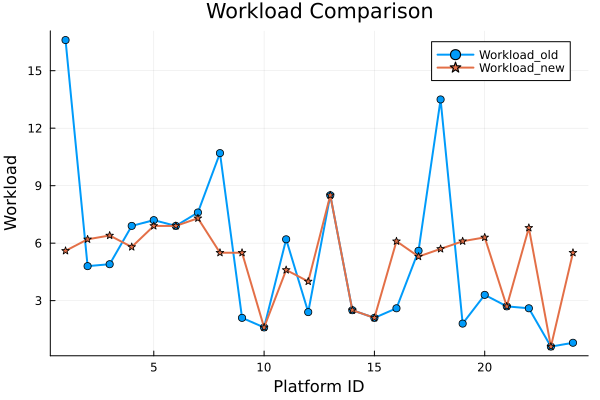

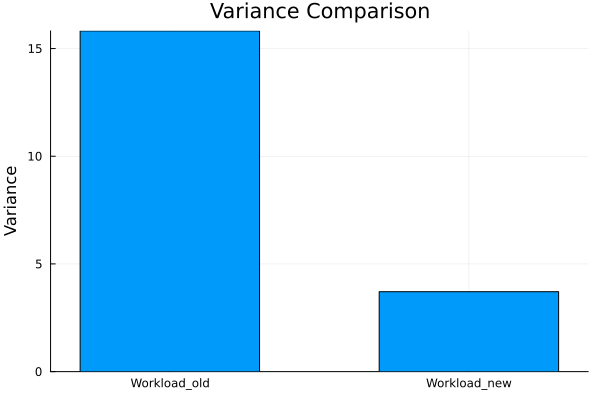

In [21]:
platform_id = 1:24
plot(platform_id, workload_1, label="Workload_old", lw=2, marker=:circle, size=(600,400))
plot!(platform_id, workload_2, label="Workload_new", lw=2, marker=:star5)

xlabel!("Platform ID")
ylabel!("Workload")
title!("Workload Comparison")
display(current())

df = DataFrame("Scenario" => ["Workload 1", "Workload 2"],"Variance" => [total_deviation_1, total_deviation_2])

bar(["Workload_old", "Workload_new"], [total_deviation_1/24, total_deviation_2/24], ylabel="Variance", title="Variance Comparison",legend=false, bar_width=0.6)

Compare these graphs, it can be concluded that this is a perfect optimization!

Finally, generate the final traffic network and police platform distribution

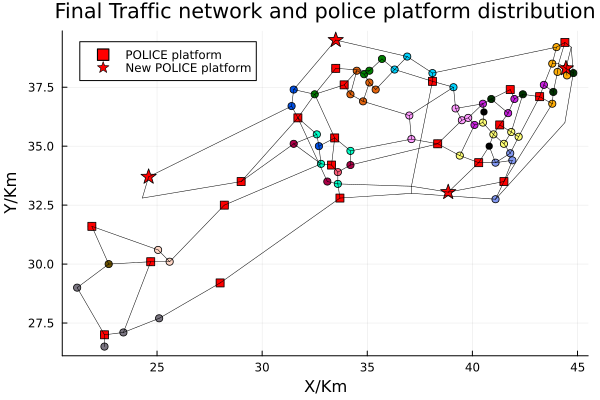

In [22]:
network_final = plot(size=(600,400))
new_platform_id = [29, 40, 61, 88]
typeof(new_platform_id)
assigned_nodes = [findall(x2_opt[i, :] .> 0.5) for i in 1:92]
colors = distinguishable_colors(24)

for platform_id in 1:24
    platform_nodes = assigned_nodes[platform_id]
   scatter!(network_final, nodes_x[platform_nodes], nodes_y[platform_nodes], color=colors[platform_id], ms=4,label="")
end

scatter!(network_final, nodes_x[1:20], nodes_y[1:20], label="POLICE platform", color=:red, ms=4, marker=:square)
scatter!(network_final, nodes_x[new_platform_id], nodes_y[new_platform_id], label="New POLICE platform", color=:red, ms=8, marker=:star)

for (i, j) in zip(links_start, links_end)
    plot!(network_final, [nodes_x[i], nodes_x[j]], [nodes_y[i], nodes_y[j]], color=:black, lw=0.5, label="")
end

xlabel!("X/Km")
ylabel!("Y/Km")
title!("Final Traffic network and police platform distribution")
plot!(network_final, grid=true, legend=true)  
display(network_final)

## 4. Results and Discussion ##

### Scenario 1: Total Service Distance Minimization  
- **Optimal distance:** Solving the assignment model to minimize the total service distance under a dispatch‐time limit of 3 minutes yields an optimal total distance of **78.77 km**.  
- **Assignment breakdown:**  
  - Platforms 1, 5, and 20 each serve 9 junctions—the heaviest loads.  
  - Platforms 6, 10, 14, and 15 each serve only 1 junction—the lightest loads.  
  - The average load is 4.6 junctions per platform, but individual loads range from 1 to 9.  
- **Far-away junctions:** Six junctions (28, 29, 38, 39, 61, 92) lie more than 3 minutes from every platform and were excluded from the model; they were later assigned manually to their nearest platforms.

[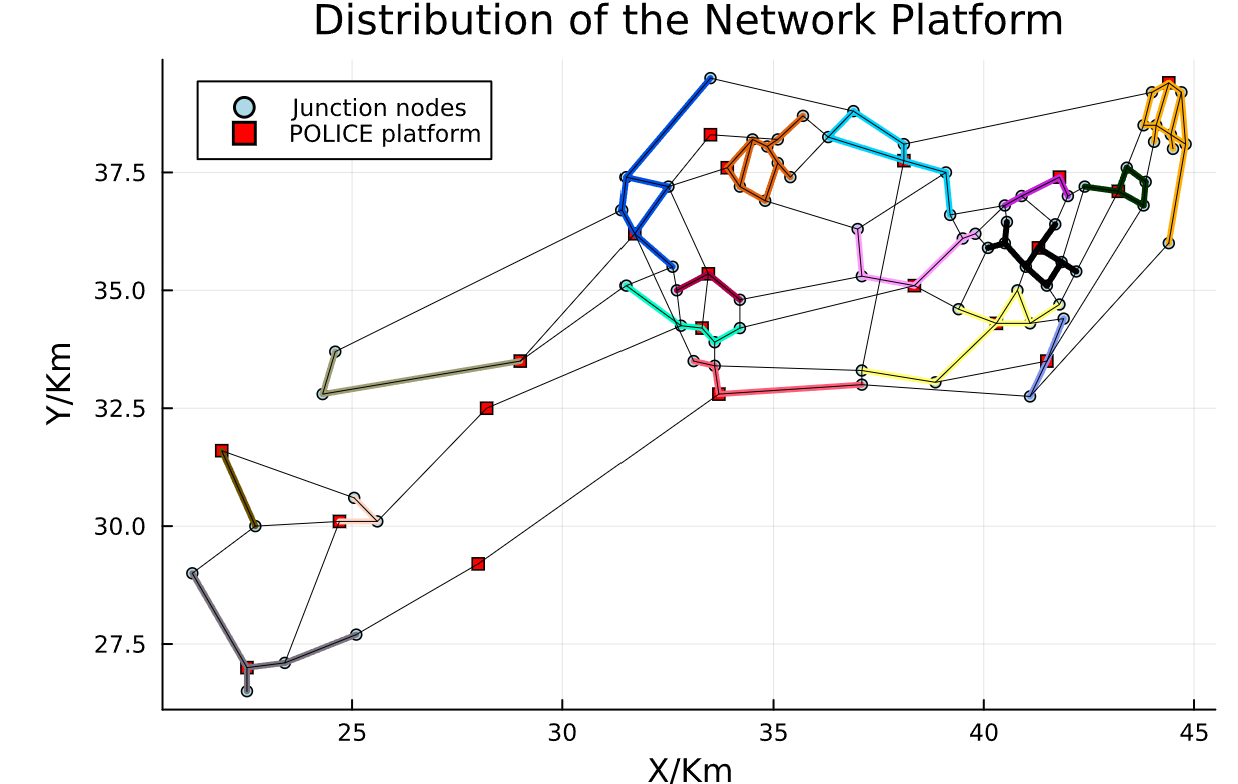](image1.png)
- **Sensitivity to dispatch limit:**  
  - If the time‐limit threshold were increased (e.g., to 4 units), fewer junctions would be excluded and the model would reassign them optimally, reducing the need for manual placement.  
  - Conversely, a stricter limit (e.g., 2.5 units) would increase the number of far-away junctions, potentially creating coverage gaps unless additional platforms are deployed.

### Scenario 2: Blocking-Time Minimization for Exit Junctions  
- **First optimal scheme:**  Formulating to minimize the maximum dispatch time per platform reduces the worst-case blocking time to **8.02 min**, however, this plan accumulates **75.26 min** of total dispatch time (sum of all blocking times), which is high.  
- **Seconde optimal scheme:** Based on the optimal maximum dispatch time, reformulating to minimize the maximum total dispatch time for all platform reduces total blocking time to **46.18 min**. The figures below show how the paths were distributed to reduce the blocking time.
  
[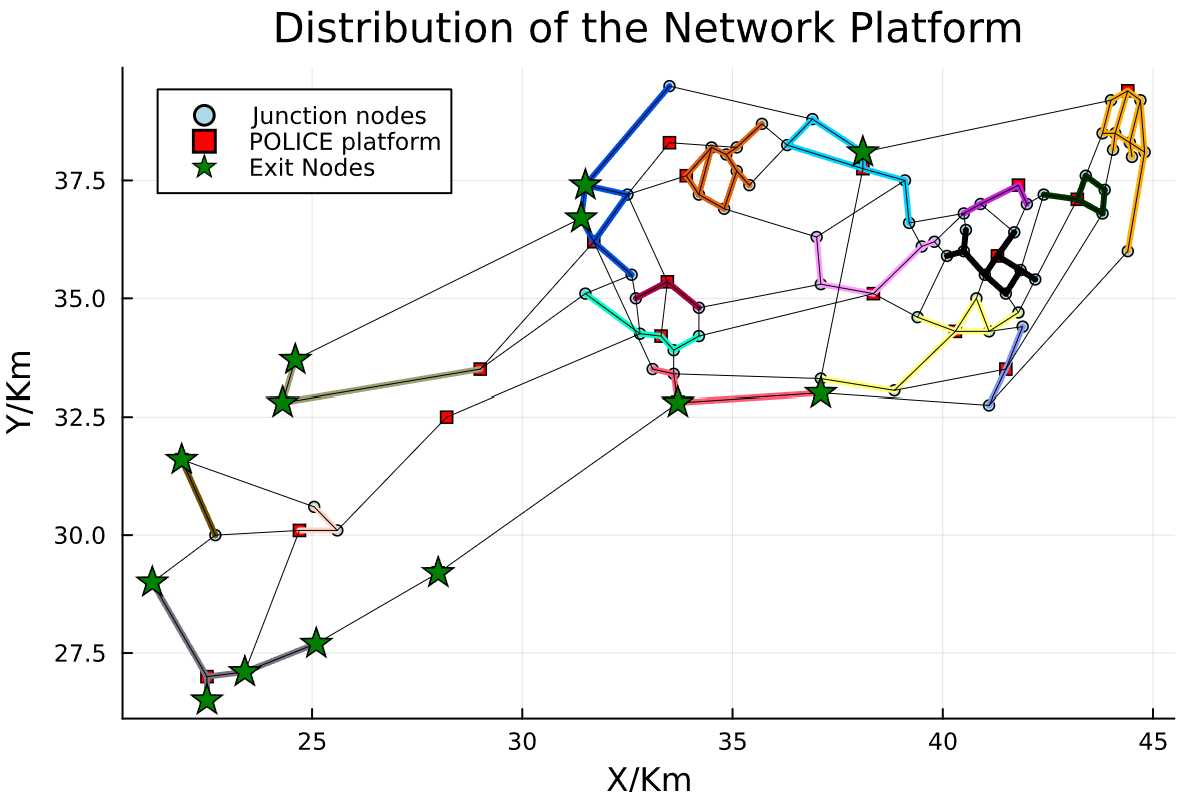](image2.png)
[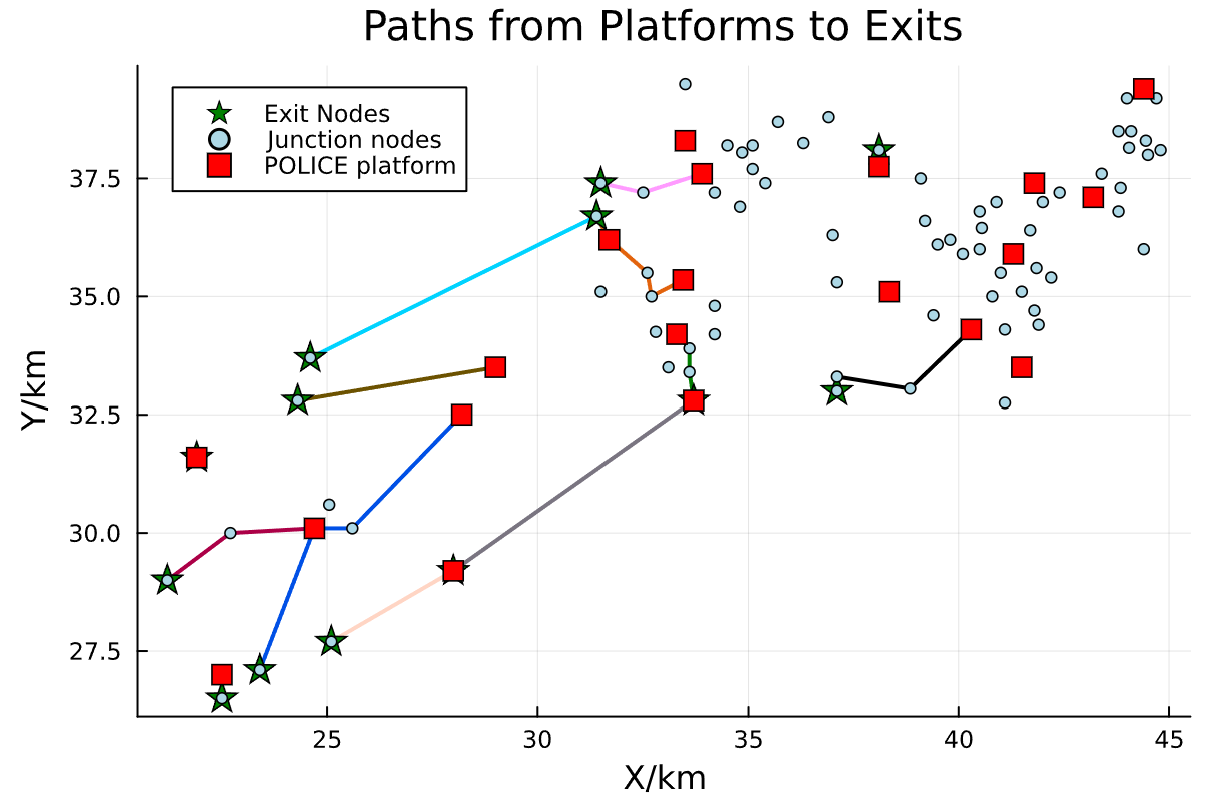](image3.png)

### Scenario 3: Workload Balancing with Four Added Platforms  
- **New platform locations:** The model selects nodes **29, 40, 61,** and **88** as the optimal sites for four additional platforms. This is shown by the figure below.

[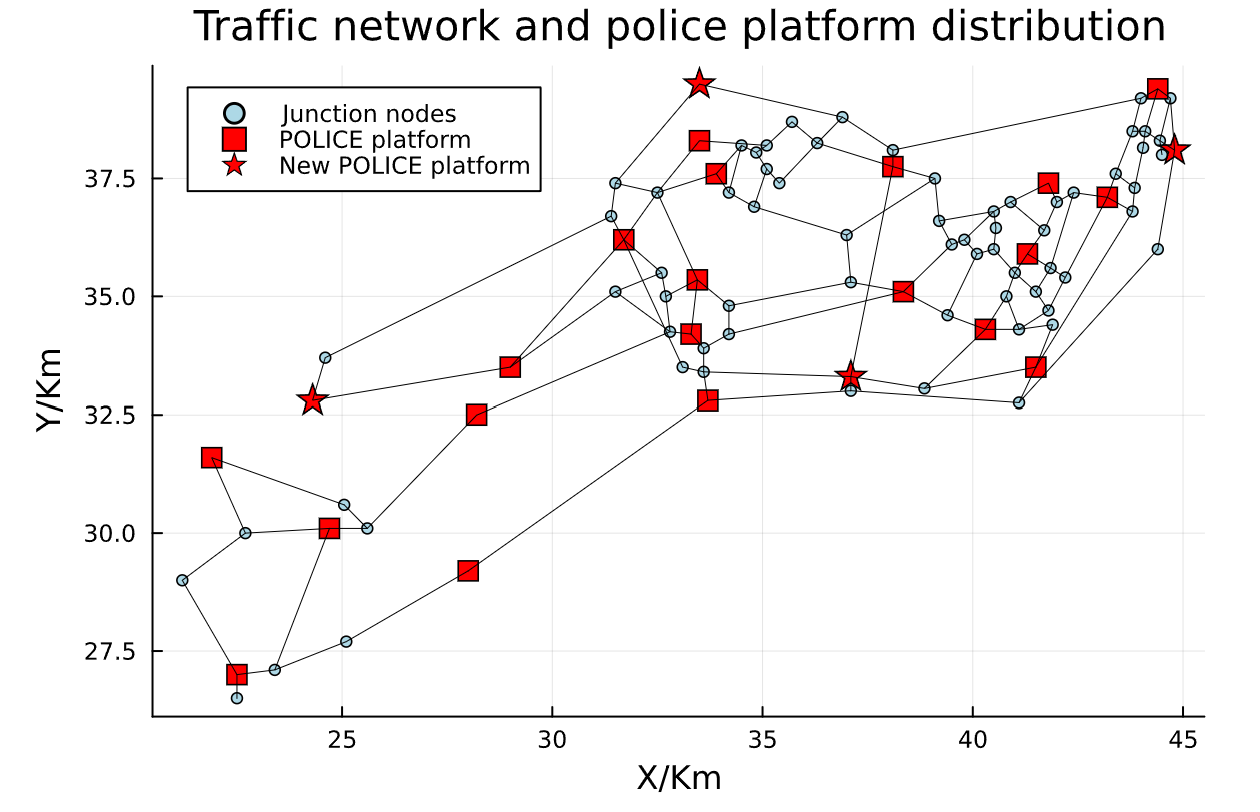](image4.png)
- **Rebalanced assignment:** With 24 platforms covering 92 junctions (Fig. 5), workloads now range from **0.6** to **8.5** junctions per platform.
- 
 [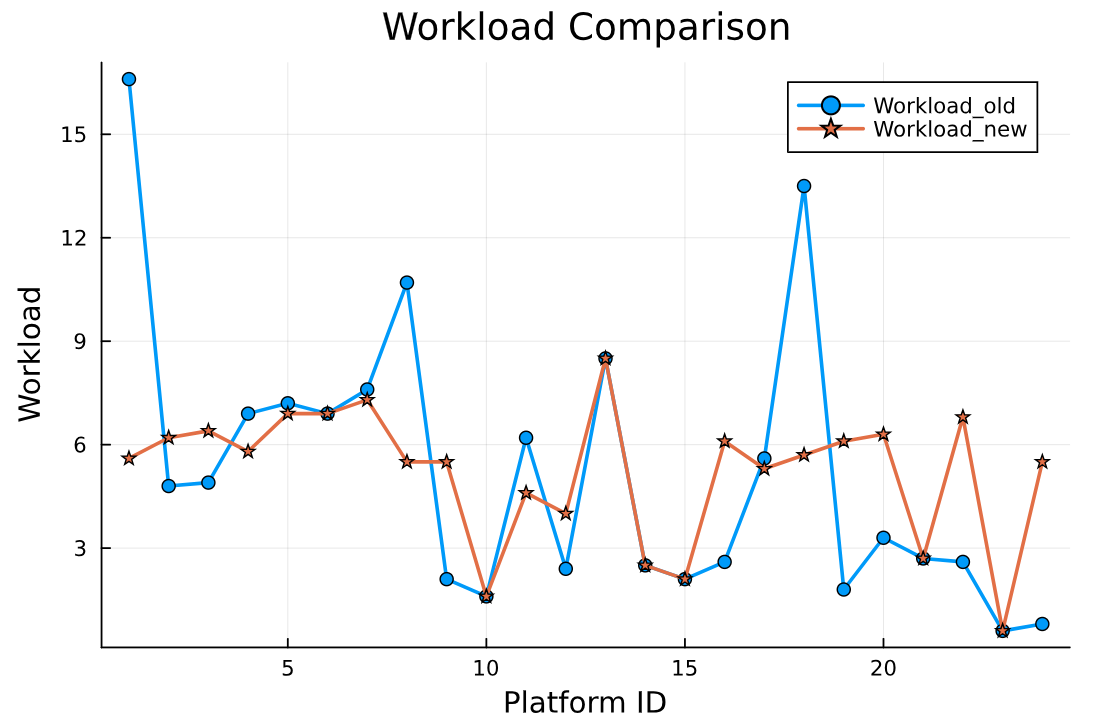](image5.png)  
- **Variance improvement:** The variance of the per-platform workload drops from **15.82** to **3.71**, compared to a higher variance under the baseline 20-platform scheme.
- **Maximum load reduction:** The heaviest workload decreases from **16.6** down to **8.5**, demonstrating a significant improvement in balance.
  
 [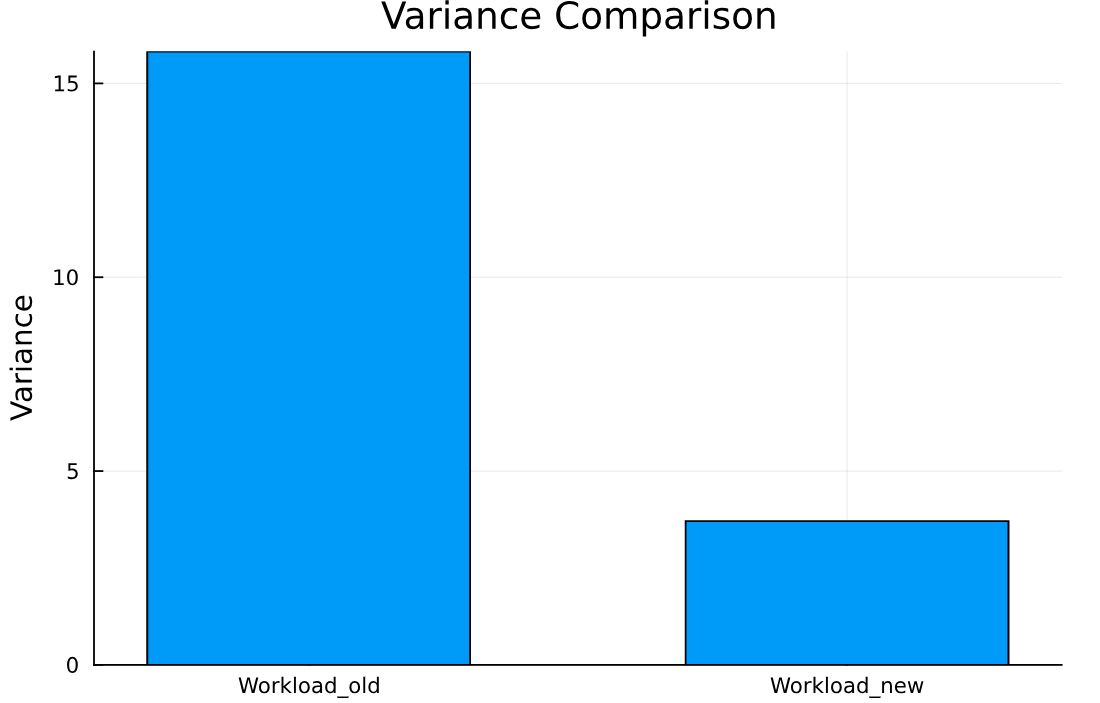](image6.png)
### Overall Insights and Sensitivity  
- **Dispatch-time limits** and **number of platforms** are critical levers: tighter time constraints mandate more platforms (or manual handling), while additional platforms yield shorter worst-case times and more even workloads.  
- **Trade-offs:** Minimizing total distance (Scenario 1) does not necessarily minimize the maximum dispatch time (Scenario 2), so objectives must be chosen to match operational priorities (coverage vs. response‐time guarantees).  

## 5. Conclusion ##

In this project, we addressed the problem of optimizing the allocation and expansion of traffic police service platforms in District A to ensure rapid and balanced emergency response. By modeling the system using binary decision variables and shortest-path distance matrices, we formulated several optimization models that targeted minimizing the maximum dispatch time and balancing the workload across platforms. We implemented a two-stage optimization approach to improve resource balance. Additional platform placements were determined based on the infeasibility of certain nodes under the time constraint and workload constraints. The proposed models were implemented and solved using JuMP in Julia, demonstrating their effectiveness in ensuring both timely response and equitable workload distribution. This work provides a quantitative and scalable framework for supporting emergency infrastructure planning.

## 6. Author Contributions

Note: The contributions in each category must sum to 100%. See Canvas for more details on what type of work belongs in each category.

#### 1. Modelling  
Blake: 33.3 % 

Yue: 33.3 %   

Hande: 33.3 %  

  
#### 2. Analysis  

Blake: 33.3 % 

Yue: 33.3 %   

Hande: 33.3 %  


#### 3. Data Gathering  

Blake: 33.3 % 

Yue: 33.3 %   

Hande: 33.3 %   


#### 4. Software Implementation  

Blake: 33.3 % 

Yue: 33.3 %   

Hande: 33.3 %   


#### 5. Report Writing  

Blake: 33.3 % 

Yue: 33.3 %   

Hande: 33.3 %   